In [18]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from ITIS_Model_funcs import get_nominal_param,OLS_res,ITIS

In [19]:
param_log,IC = get_nominal_param()
IC = [ 2.0,          0.,          0.14759607,  0.,         13.75484703,  3.13344442, 15.73028492,  1.38649737]

D = '1'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '1'   # '1' for 25, '2' for 13

if D == '1':
    output_ids = [6,7]
elif D == '2':
    output_ids = [3,6,7]
else:
    output_ids = [3,4,6,7]

with open('syntheticData\\TRUE_SOL' + D + dpoints + '.pkl', 'rb') as f:
    results = pickle.load(f)

t_data = results['t_data']
y_data = results['y_data']

##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_log)
n_states = len(output_ids)

S = np.zeros((n_param, len(t_data) * n_states)) ##Initialize shape of sensitivity matrix.

for i in range(n_param):  #calculate the relative residual sensitivity to each 45 parameters

        param_in = param_log[i]
        param_delta = param_in + h
##RIGHT NOW THIS IS BEING CALCULATED WITH NOISELESS DATA
        S[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, i, output_ids, param_log, IC)
                                            - OLS_res(param_in, y_data, t_data, i, output_ids, param_log, IC)))

In [20]:
##import rankings from global analysis
with open('paramRankings\\rankingDesign' + D + '.pkl', 'rb') as f:
    results = pickle.load(f)

rank_value = results['rank_value']      # sorted ranking values
param_sorted = results['param_sorted']  #accordingly sorted params as strings
rank_cut = np.array(rank_value)[np.array(rank_value) > .25 * np.array(rank_value)[0]]
param_sorted = np.array(param_sorted)[:len(rank_cut)]

param_titles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

circadian_param = ['alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc'] #exclude?

cond = 0
unid = []
p_indices = [param_titles.index(param_sorted[0])]
for i in range(1,len(rank_cut)):
    p_indices.append(param_titles.index(param_sorted[i]))
    S_opt = S[p_indices,:].copy()
    F_opt = S_opt@S_opt.T
    cond = np.linalg.cond(F_opt)
    if cond > 1e+6:
        unid.append(p_indices.pop())
        print("Removed: ", unid[-1])


S_opt = S[p_indices,:].copy()
F_opt = S_opt@S_opt.T
C_opt = np.linalg.inv(F_opt)
selected = [param_titles[i] for i in p_indices]
print("Design : ", D + dpoints)
print("Number of selected parameters:", len(p_indices))
print("Selected Parameters: ",  selected)
print(p_indices)
print("Excluded Parameters: ", [param_titles[i] for i in unid])
print("Condition Number of F:", np.linalg.cond(F_opt))
print("Diagonals of C:", np.diag(C_opt))

Design :  11
Number of selected parameters: 15
Selected Parameters:  ['d7', 'h6', 'd8', 'T', 'h11', 'beta', 'k3', 'd4', 'k14', 'h7', 'alpha', 'h4', 'k4', 'd6', 'k6']
[33, 12, 36, 43, 32, 39, 7, 16, 31, 15, 37, 9, 8, 28, 14]
Excluded Parameters:  []
Condition Number of F: 13940.444998223184
Diagonals of C: [0.40056127 0.47961845 0.18585825 0.24353508 0.04412121 0.97808704
 0.08591591 0.14502593 0.06896645 0.15683362 1.35668603 0.55899079
 0.0635271  0.81366274 1.68333637]


<BarContainer object of 15 artists>

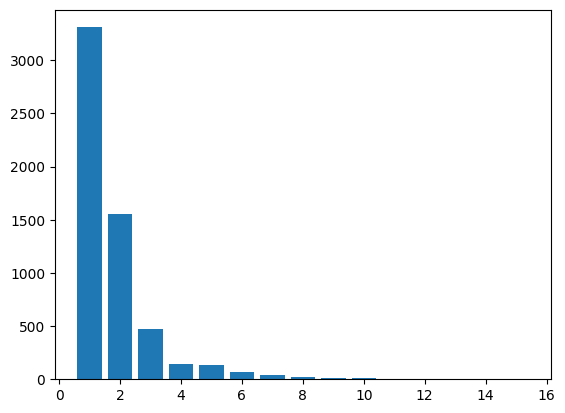

In [21]:
F_eigen = np.linalg.eigvals(F_opt)
plt.figure()
plt.bar(np.linspace(1,len(p_indices),len(p_indices)),F_eigen)


<BarContainer object of 45 artists>

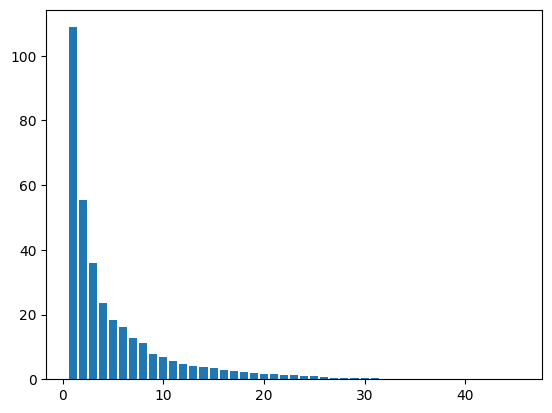

In [22]:
U, S_svd, V = np.linalg.svd(S)
plt.figure()
plt.bar(np.linspace(1,len(param_titles),len(param_titles)), S_svd)

#implement choosing algorithm using this?

In [23]:
#Complete F
F = S@S.T
C = np.linalg.inv(F)
print("Condition Number of F:", np.linalg.cond(F))
print(np.linalg.matrix_rank(F))
print("Diagonals of F:", np.diag(F))
print("Diagonals of C:", np.diag(C))
diag = np.diag(C)
unid = [param_titles[i] for i in list(np.where(diag > 1e+3))[0]]
print("Unidentifiable:", unid) ##this isn't really useful right now

Condition Number of F: 79341054796917.48
45
Diagonals of F: [6.33830152e+00 7.65468967e+01 4.45328873e+01 8.60807895e+02
 8.76742380e+02 7.68857217e+02 1.06111974e+03 6.16393446e+02
 7.16493744e+02 4.01613551e+01 7.93086637e+02 4.38311909e+02
 2.77155370e+02 4.04453592e+01 2.57264886e+01 6.05277316e+02
 6.31849522e+02 5.95999350e+02 3.39044067e+01 5.11695402e+02
 7.21506223e+02 3.72332284e+02 6.23783056e+01 8.78559953e+02
 7.32576946e-04 1.09923739e+02 2.09931399e+01 9.25064135e+02
 8.04915595e+01 9.73112777e+02 9.03115905e+02 6.70385037e+02
 9.80050793e+02 3.81969164e+02 8.73672015e+02 4.99179405e+01
 2.77163862e+02 4.54064848e+01 1.42294716e+00 1.11101046e+02
 4.76484421e+00 8.22779305e+01 1.64551954e+00 3.20750153e+02
 2.09948103e+01]
Diagonals of C: [1.24814028e+05 5.42766622e+04 1.85713585e+06 4.03573334e+02
 5.48562202e+01 4.70749144e+01 4.24859005e+02 7.88647649e+01
 2.70207649e+01 1.31166111e+04 4.52002388e+02 4.70082516e+01
 3.35811354e+03 8.52582800e+04 1.96851350e+04 1.35651

In [24]:
##SAVE FUNCTIONALITY

# all_results = {
#     'S': S,
#     'S_opt': S_opt,
# }
#
# with open('Sensitivities\\sens' + D + dpoints + '.pkl', 'wb') as f:
#     pickle.dump(all_results, f)

In [27]:
##Calculating CIS
from scipy import stats

##Retrieve standard errors?
SE = np.sqrt(np.diag(C_opt)) ####NOT RIGHT. FIGURE IT OUT AND FIX

##initialize container for bounds
CI = np.zeros((len(param_sorted),2))
alpha = 0.05
t_value = stats.t.ppf(1-alpha, len(t_data))

for i in range(len(param_sorted)):
    print(param_log[p_indices[i]])
    CI[i,0] = param_log[p_indices[i]] - t_value * SE[i]
    CI[i,1] = param_log[p_indices[i]] + t_value * SE[i]
    print(CI[i,0], CI [i,1])

##HOW DOES LOG SCALE AFFECT OUTCOME?

-4.135166556742356
-5.2162473098517435 -3.0540858036329688
-1.8394802054394668
-3.022444396577641 -0.6565160143012923
-3.6268440631944836
-4.3632454263518925 -2.8904427000370743
7.272398392570047
6.429443343681159 8.115353441458934
4.382026634673881
4.02323080795953 4.740822461388232
6.856461984594587
5.167140094607428 8.545783874581744
-20.287594886781182
-20.788275138460996 -19.78691463510137
-3.5301677629591155
-4.1806665511860475 -2.879668974732184
4.718498871295094
4.269916085757761 5.167081656832427
7.345687577227803
6.669225828155631 8.022149326299976
5.703782474656201
3.7141936509125495 7.693371298399852
6.214608098422191
4.937504929621047 7.4917112672233355
-0.6931471805599453
-1.1236769195320688 -0.26261744158782163
-3.4420193761824103
-4.9828179572850395 -1.9012207950797808
10.47768226391878
8.261481450156602 12.693883077680958
